In [ ]:
from google.colab import files
files.upload()

Saving ecommerce_completed_dataset1.csv to ecommerce_completed_dataset1.csv


{'ecommerce_completed_dataset1.csv': b'Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Order ID,Customer_ID,Price,Discount,Delivery Time,Shipping Mode,Customer Rating,Customer Segment,Returned,Return Reason,Return\r\n31-12-2024,Printer,Office,North,4,3640,348.93,1,ABC0001,910,33,4,Same Day,3.5,Premium,No,Not Returned,No\r\n27-11-2022,Mouse,Accessories,East,7,1197,106.53,2,ABC0002,171,19,7,Same Day,2.8,Regular,Yes,Not Returned,No\r\n11-05-2022,Tablet,Electronics,South,5,5865,502.73,3,ABC0003,1173,12,1,Standard,5,Premium,No,Not Returned,No\r\n16-03-2024,Mouse,Accessories,South,2,786,202.87,4,ABC0004,393,25,7,Standard,2.9,Regular,Yes,Not Returned,No\r\n10-09-2022,Mouse,Accessories,West,1,509,103.28,5,ABC0005,509,23,8,Same Day,3.2,Regular,No,Not Returned,No\r\n01-12-2023,Camera,Electronics,West,1,524,106.35,6,ABC0006,524,27,5,Express,3.3,Regular,No,Not Returned,No\r\n09-10-2023,Headphones,Accessories,North,7,6167,1027.98,7,ABC0007,881,15,2,Same Day,4.6,Premium,No,Not Returned

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("ecommerce_completed_dataset1.csv")

In [ ]:
df.shape

(3500, 18)

In [ ]:
df["Return"] = np.where(df["Profit"] < 0, "Yes", "No")
df["Return"].value_counts()

In [ ]:
import numpy as np
import pandas as pd

# assuming your dataset is already loaded as df

# 1. Price
df["Price"] = df["Sales"] / df["Quantity"]

# 2. Discount (random realistic values)
np.random.seed(42)
df["Discount"] = np.random.randint(5, 40, len(df))

# 3. Delivery Time
df["Delivery Time"] = np.random.randint(1, 13, len(df))

# 4. Shipping Mode
df["Shipping Mode"] = np.random.choice(
    ["Standard", "Express", "Same Day"], len(df)
)

# 5. Customer Rating (based on profit + randomness)
df["Customer Rating"] = np.clip(
    5 - (df["Delivery Time"] / 3) + np.random.normal(0, 0.5, len(df)),
    1, 5
).round(1)

# 6. Customer Segment
df["Customer Segment"] = np.where(
    df["Sales"] > df["Sales"].median(),
    "Premium",
    "Regular"
)

# 7. Returned (logic-based)
df["Returned"] = np.where(
    (df["Customer Rating"] < 3) | (df["Profit"] < 100),
    "Yes",
    "No"
)

# 8. Return Reason
conditions = [
    df["Customer Rating"] < 2.5,
    df["Delivery Time"] > 8,
    df["Profit"] < 100
]

choices = ["Low Rating", "Late Delivery", "Product Issue"]

df["Return Reason"] = np.select(conditions, choices, default="Not Returned")

df.head()

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order Date        3500 non-null   object 
 1   Product Name      3500 non-null   object 
 2   Category          3495 non-null   object 
 3   Region            3496 non-null   object 
 4   Quantity          3498 non-null   float64
 5   Sales             3500 non-null   int64  
 6   Profit            3500 non-null   float64
 7   Order ID          3500 non-null   object 
 8   Customer_ID       3500 non-null   object 
 9   Price             3500 non-null   int64  
 10  Discount          3500 non-null   int64  
 11  Delivery Time     3500 non-null   int64  
 12  Shipping Mode     3500 non-null   object 
 13  Customer Rating   3500 non-null   float64
 14  Customer Segment  3500 non-null   object 
 15  Returned          3500 non-null   object 
 16  Return Reason     3500 non-null   object 


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Order ID,Customer_ID,Price,Discount,Delivery Time,Shipping Mode,Customer Rating,Customer Segment,Returned,Return Reason,Return
0,31-12-2024,Printer,Office,North,4.0,3640,348.93,1,ABC0001,910,33,4,Same Day,3.5,Premium,No,Not Returned,No
1,27-11-2022,Mouse,Accessories,East,7.0,1197,106.53,2,ABC0002,171,19,7,Same Day,2.8,Regular,Yes,Not Returned,No
2,11-05-2022,Tablet,Electronics,South,5.0,5865,502.73,3,ABC0003,1173,12,1,Standard,5.0,Premium,No,Not Returned,No
3,16-03-2024,Mouse,Accessories,South,2.0,786,202.87,4,ABC0004,393,25,7,Standard,2.9,Regular,Yes,Not Returned,No
4,10-09-2022,Mouse,Accessories,West,1.0,509,103.28,5,ABC0005,509,23,8,Same Day,3.2,Regular,No,Not Returned,No


In [ ]:
df.to_csv("ecommerce_completed_dataset1.csv", index=False)
from google.colab import files
files.download("ecommerce_completed_dataset1.csv")

NameError: name 'df' is not defined

In [ ]:
#Understand feature definitions
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit', 'Order ID', 'Customer_ID', 'Price', 'Discount',
       'Delivery Time', 'Shipping Mode', 'Customer Rating', 'Customer Segment',
       'Returned', 'Return Reason', 'Return'],
      dtype='object')

In [ ]:
df.describe()

,Quantity,Sales,Profit,Price,Discount,Delivery Time,Customer Rating
count,3498.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,4.930818,3047.966000,527.047203,616.468571,22.236857,6.541429,2.831600
std,2.576108,2440.213237,504.139732,331.674767,10.158682,3.437391,1.188706
min,1.000000,51.000000,6.970000,50.000000,5.000000,1.000000,1.000000
25%,3.000000,1049.500000,158.695000,325.000000,13.000000,4.000000,1.800000
50%,5.000000,2350.500000,361.070000,617.000000,23.000000,7.000000,2.800000
75%,7.000000,4537.000000,729.125000,897.000000,31.000000,10.000000,3.800000
max,9.000000,10782.000000,2946.930000,1198.000000,39.000000,12.000000,5.000000


In [ ]:
for col in df.columns:
    print(col)
    print(df[col].head(3))
    print("-"*30)

Order Date
0    31-12-2024
1    27-11-2022
2    11-05-2022
Name: Order Date, dtype: object
------------------------------
Product Name
0    Printer
1      Mouse
2     Tablet
Name: Product Name, dtype: object
------------------------------
Category
0         Office
1    Accessories
2    Electronics
Name: Category, dtype: object
------------------------------
Region
0    North
1     East
2    South
Name: Region, dtype: object
------------------------------
Quantity
0    4.0
1    7.0
2    5.0
Name: Quantity, dtype: float64
------------------------------
Sales
0    3640
1    1197
2    5865
Name: Sales, dtype: int64
------------------------------
Profit
0    348.93
1    106.53
2    502.73
Name: Profit, dtype: float64
------------------------------
Order ID
0    1
1    2
2    3
Name: Order ID, dtype: object
------------------------------
Customer_ID
0    ABC0001
1    ABC0002
2    ABC0003
Name: Customer_ID, dtype: object
------------------------------
Price
0     910
1     171
2    1173
Name:

In [ ]:
#Identify missing values
df.isnull().sum()


,0
Order Date,0
Product Name,0
Category,5
Region,4
Quantity,2
Sales,0
Profit,0
Order ID,0
Customer_ID,0
Price,0


In [ ]:
df.to_csv("ecommerce_completed_dataset1.csv", index=False)
from google.colab import files
files.download("ecommerce_completed_dataset1.csv")
df = df.mask(np.random.random(df.shape) < 0.05)
df.isnull().sum()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,0
Order Date,363
Product Name,332
Category,349
Region,359
Quantity,358
Sales,303
Profit,317
Order ID,3500
Customer_ID,3500
Price,328


In [ ]:
df = df.drop_duplicates()
print(df)

      Order Date Product Name     Category Region  Quantity  Sales   Profit  \
0     31-12-2024      Printer       Office  North       4.0   3640   348.93   
1     27-11-2022        Mouse  Accessories   East       7.0   1197   106.53   
2     11-05-2022       Tablet  Electronics  South       5.0   5865   502.73   
3     16-03-2024        Mouse  Accessories  South       2.0    786   202.87   
4     10-09-2022        Mouse  Accessories   West       1.0    509   103.28   
...          ...          ...          ...    ...       ...    ...      ...   
3495  15-02-2023      Monitor  Accessories  North       4.0   4064   771.16   
3496  18-09-2022      Monitor  Accessories   East       1.0   1117   119.89   
3497  12-04-2022       Laptop  Electronics  South       4.0    260    66.02   
3498  18-01-2022      Printer       Office  South       3.0    222    50.28   
3499  01-11-2024   Smartwatch  Electronics   East       9.0  10530  1777.32   

     Order ID Customer_ID  Price  Discount  Deliver

In [ ]:
#3500 orders, 2117 returned

In [ ]:
print(df.mean(numeric_only=True))

Quantity              4.930818
Sales              3047.966000
Profit              527.047203
Price               616.468571
Discount             22.236857
Delivery Time         6.541429
Customer Rating       2.831600
dtype: float64


In [ ]:
print(df.median(numeric_only=True))

Quantity              5.00
Sales              2350.50
Profit              361.07
Price               617.00
Discount             23.00
Delivery Time         7.00
Customer Rating       2.80
dtype: float64


In [ ]:
print(df.std(numeric_only=True))

Quantity              2.576108
Sales              2440.213237
Profit              504.139732
Price               331.674767
Discount             10.158682
Delivery Time         3.437391
Customer Rating       1.188706
dtype: float64


In [ ]:
print(df["Sales"].quantile([0.25, 0.50, 0.75]))
print(df["Profit"].quantile([0.25, 0.50, 0.75]))
print(df["Price"].quantile([0.25, 0.50, 0.75]))
print(df["Discount"].quantile([0.25, 0.50, 0.75]))

0.25    1049.5
0.50    2350.5
0.75    4537.0
Name: Sales, dtype: float64
0.25    158.695
0.50    361.070
0.75    729.125
Name: Profit, dtype: float64
0.25    325.0
0.50    617.0
0.75    897.0
Name: Price, dtype: float64
0.25    13.0
0.50    23.0
0.75    31.0
Name: Discount, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

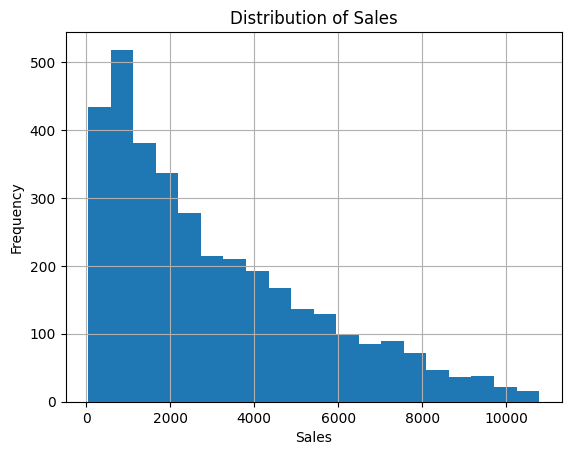

In [ ]:
df["Sales"].hist(bins=20)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df["Return"] = df["Returned"].map({"Yes": 1, "No": 0})

In [ ]:
category_return = df.groupby("Category")["Return"].mean() * 100
print(category_return)

Category
Accessories    60.456817
Electronics    60.333909
Office         61.064426
Name: Return, dtype: float64


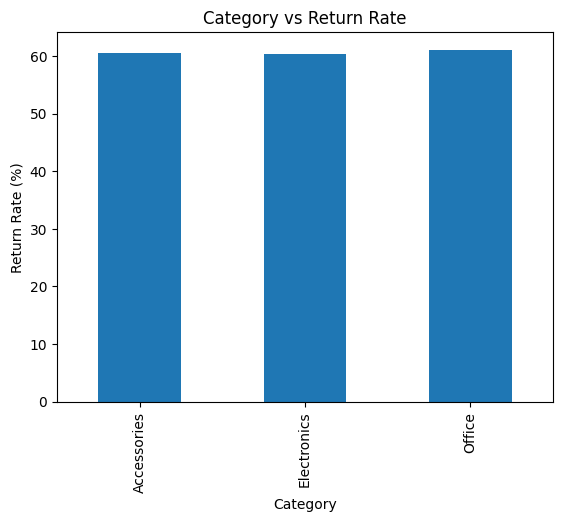

In [ ]:
import matplotlib.pyplot as plt

category_return.plot(kind="bar")
plt.title("Category vs Return Rate")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.show()

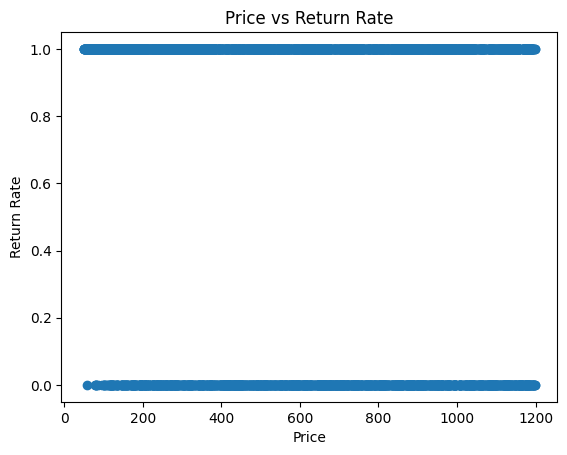

In [ ]:
plt.scatter(df["Price"], df["Return"])
plt.title("Price vs Return Rate")
plt.xlabel("Price")
plt.ylabel("Return Rate")
plt.show()

In [ ]:
delivery_return = df.groupby("Delivery Time")["Return"].mean() * 100
print(delivery_return)

Delivery Time
1      16.312057
2      16.838488
3      14.487633
4      21.107266
5      31.203008
6      53.968254
7      76.780186
8      93.031359
9      95.488722
10    100.000000
11    100.000000
12    100.000000
Name: Return, dtype: float64


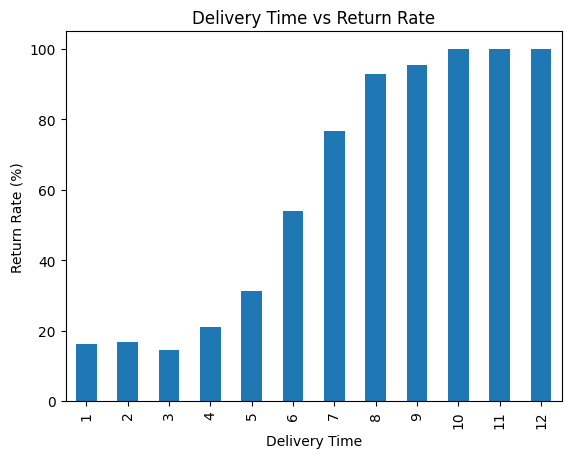

In [ ]:
delivery_return.plot(kind="bar")
plt.title("Delivery Time vs Return Rate")
plt.xlabel("Delivery Time")
plt.ylabel("Return Rate (%)")
plt.show()

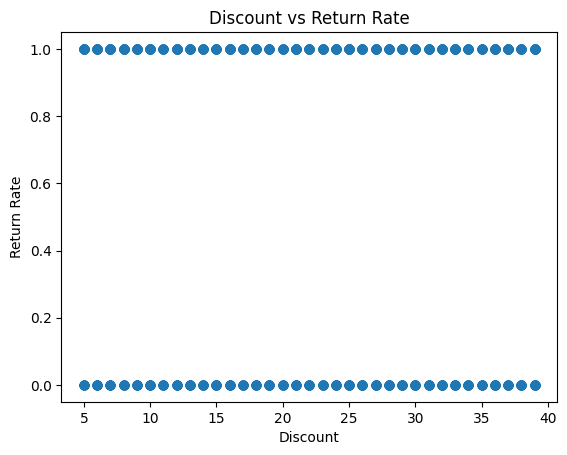

In [ ]:
plt.scatter(df["Discount"], df["Return"])
plt.title("Discount vs Return Rate")
plt.xlabel("Discount")
plt.ylabel("Return Rate")
plt.show()

Customer Rating
1.0    100.000000
1.1    100.000000
1.2    100.000000
1.3    100.000000
1.4    100.000000
1.5    100.000000
1.6    100.000000
1.7    100.000000
1.8    100.000000
1.9    100.000000
2.0    100.000000
2.1    100.000000
2.2    100.000000
2.3    100.000000
2.4    100.000000
2.5    100.000000
2.6    100.000000
2.7    100.000000
2.8    100.000000
2.9    100.000000
3.0     21.111111
3.1     13.580247
3.2     19.417476
3.3     12.328767
3.4     23.255814
3.5     13.333333
3.6     15.909091
3.7      9.900990
3.8     15.841584
3.9     12.643678
4.0     16.304348
4.1     15.476190
4.2      9.859155
4.3     15.068493
4.4     17.910448
4.5     13.114754
4.6     10.869565
4.7     15.789474
4.8     16.666667
4.9     12.500000
5.0     14.285714
Name: Return, dtype: float64


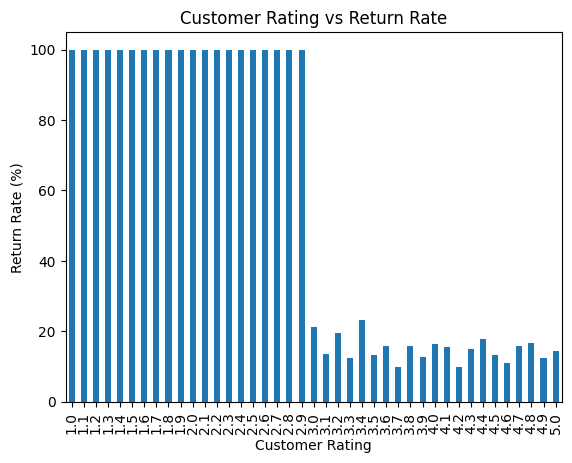

In [ ]:
rating_return = df.groupby("Customer Rating")["Return"].mean() * 100
print(rating_return)

rating_return.plot(kind="bar")
plt.title("Customer Rating vs Return Rate")
plt.xlabel("Customer Rating")
plt.ylabel("Return Rate (%)")
plt.show()

In [ ]:
return_count = df[df["Returned"] == "Yes"].groupby("Customer_ID").size()
print(return_count.sort_values(ascending=False))

Customer_ID
ABC3499    1
ABC0002    1
ABC0004    1
ABC0010    1
ABC0016    1
          ..
ABC0026    1
ABC0025    1
ABC0021    1
ABC0020    1
ABC0019    1
Length: 2117, dtype: int64


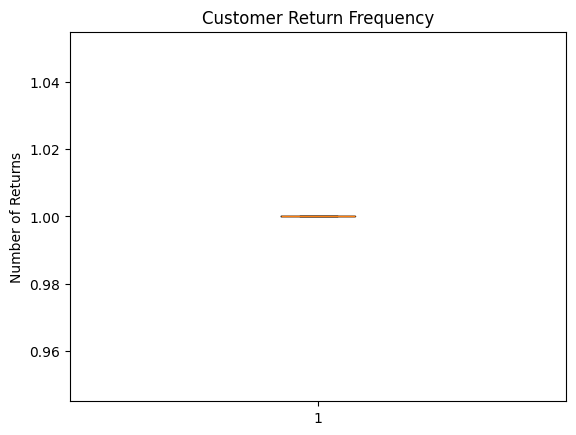

In [ ]:
plt.boxplot(return_count)
plt.title("Customer Return Frequency")
plt.ylabel("Number of Returns")
plt.show()

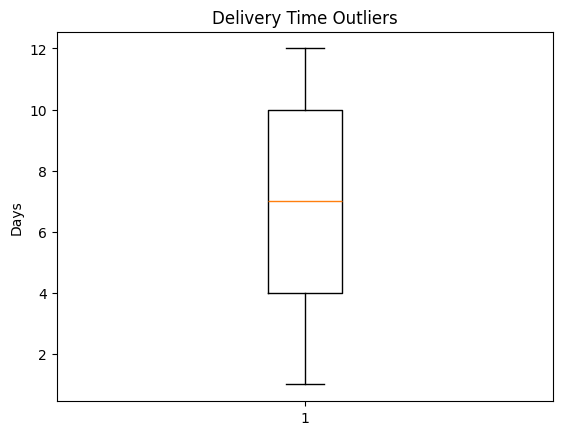

In [ ]:
plt.boxplot(df["Delivery Time"])
plt.title("Delivery Time Outliers")
plt.ylabel("Days")
plt.show()

In [ ]:
Q1 = df["Delivery Time"].quantile(0.25)
Q3 = df["Delivery Time"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Delivery Time"] < lower) | (df["Delivery Time"] > upper)]

print(outliers)

Empty DataFrame
Columns: [Order Date, Product Name, Category, Region, Quantity, Sales, Profit, Order ID, Customer_ID, Price, Discount, Delivery Time, Shipping Mode, Customer Rating, Customer Segment, Returned, Return Reason, Return]
Index: []


In [ ]:
from scipy.stats import zscore

df["Zscore"] = zscore(df["Delivery Time"])

outliers = df[df["Zscore"].abs() > 3]

print(outliers)

Empty DataFrame
Columns: [Order Date, Product Name, Category, Region, Quantity, Sales, Profit, Order ID, Customer_ID, Price, Discount, Delivery Time, Shipping Mode, Customer Rating, Customer Segment, Returned, Return Reason, Return, Zscore]
Index: []


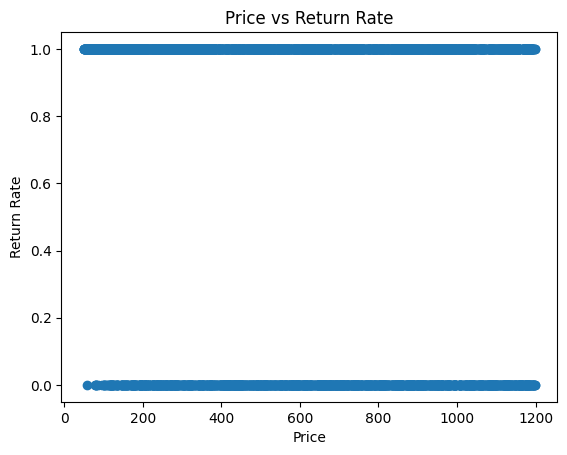

In [ ]:
plt.scatter(df["Price"], df["Return"])
plt.title("Price vs Return Rate")
plt.xlabel("Price")
plt.ylabel("Return Rate")
plt.show()

In [ ]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = df[(df["Price"] < lower) | (df["Price"] > upper)]

print(price_outliers)

Empty DataFrame
Columns: [Order Date, Product Name, Category, Region, Quantity, Sales, Profit, Order ID, Customer_ID, Price, Discount, Delivery Time, Shipping Mode, Customer Rating, Customer Segment, Returned, Return Reason, Return, Zscore]
Index: []


In [ ]:
from scipy.stats import zscore

df["Price_Z"] = zscore(df["Price"])

price_outliers = df[df["Price_Z"].abs() > 3]

print(price_outliers)

Empty DataFrame
Columns: [Order Date, Product Name, Category, Region, Quantity, Sales, Profit, Order ID, Customer_ID, Price, Discount, Delivery Time, Shipping Mode, Customer Rating, Customer Segment, Returned, Return Reason, Return, Zscore, Price_Z]
Index: []


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

returned = df[df["Returned"] == "Yes"]["Delivery Time"]
not_returned = df[df["Returned"] == "No"]["Delivery Time"]

t_stat, p_value = ttest_ind(returned, not_returned)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Delivery delay significantly affects return behavior.")
else:
    print("Fail to reject H0")
    print("Delivery delay has no significant effect on return behavior.")

T-statistic: 57.81322766579587
P-value: 0.0
Reject H0
Delivery delay significantly affects return behavior.


In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Category"], df["Returned"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Reject H0")
    print("Category and return behavior are significantly associated.")
else:
    print("Fail to reject H0")
    print("No significant association between category and returns.")

Chi-square: 0.06610657965108971
P-value: 0.9674870010017699
Fail to reject H0
No significant association between category and returns.


In [ ]:
#Delivery time has a statistically significant impact on product returns. Faster deliveries may reduce return rates, so the company should improve shipping performance.

In [ ]:
high_return = df[df["Returned"]=="Yes"].groupby("Customer_ID").size().reset_index(name="Return_Count")

high_return = high_return.sort_values(by="Return_Count", ascending=False)

print(high_return)

     Customer_ID  Return_Count
2116     ABC3499             1
0        ABC0002             1
1        ABC0004             1
2        ABC0010             1
3        ABC0016             1
...          ...           ...
9        ABC0026             1
8        ABC0025             1
7        ABC0021             1
6        ABC0020             1
5        ABC0019             1

[2117 rows x 2 columns]


In [ ]:
discount_customer = df.groupby("Customer_ID")["Discount"].mean().reset_index()

discount_customer = discount_customer.sort_values(by="Discount", ascending=False)

print(discount_customer)

     Customer_ID  Discount
3464     ABC3465      39.0
2624     ABC2625      39.0
2586     ABC2587      39.0
1498     ABC1499      39.0
3484     ABC3485      39.0
...          ...       ...
760      ABC0761       5.0
2533     ABC2534       5.0
468      ABC0469       5.0
3467     ABC3468       5.0
1035     ABC1036       5.0

[3500 rows x 2 columns]


In [ ]:
premium_customer = df.groupby("Customer_ID")["Price"].mean().reset_index()

premium_customer = premium_customer.sort_values(by="Price", ascending=False)

print(premium_customer)

     Customer_ID   Price
1821     ABC1822  1198.0
1340     ABC1341  1198.0
3160     ABC3161  1198.0
1127     ABC1128  1198.0
798      ABC0799  1197.0
...          ...     ...
3436     ABC3437    51.0
256      ABC0257    51.0
2894     ABC2895    50.0
2962     ABC2963    50.0
511      ABC0512    50.0

[3500 rows x 2 columns]


In [ ]:
delay_customer = df.groupby("Customer_ID")["Delivery Time"].mean().reset_index()

delay_customer = delay_customer.sort_values(by="Delivery Time", ascending=False)

print(delay_customer)

     Customer_ID  Delivery Time
3467     ABC3468           12.0
9        ABC0010           12.0
3269     ABC3270           12.0
3264     ABC3265           12.0
3263     ABC3264           12.0
...          ...            ...
57       ABC0058            1.0
85       ABC0086            1.0
2661     ABC2662            1.0
2658     ABC2659            1.0
2657     ABC2658            1.0

[3500 rows x 2 columns]


In [ ]:
low_rating = df.groupby("Customer_ID")["Customer Rating"].mean().reset_index()

low_rating = low_rating.sort_values(by="Customer Rating")

print(low_rating)

     Customer_ID  Customer Rating
3101     ABC3102              1.0
416      ABC0417              1.0
3049     ABC3050              1.0
432      ABC0433              1.0
430      ABC0431              1.0
...          ...              ...
2        ABC0003              5.0
14       ABC0015              5.0
2382     ABC2383              5.0
23       ABC0024              5.0
3487     ABC3488              5.0

[3500 rows x 2 columns]


In [ ]:


customer_behavior = df.groupby("Customer_ID").agg({
    "Return":"mean",
    "Price":"mean",
    "Discount":"mean",
    "Delivery Time":"mean",
    "Customer Rating":"mean"
})

print(customer_behavior)

             Return   Price  Discount  Delivery Time  Customer Rating
Customer_ID                                                          
ABC0001         0.0   910.0      33.0            4.0              3.5
ABC0002         1.0   171.0      19.0            7.0              2.8
ABC0003         0.0  1173.0      12.0            1.0              5.0
ABC0004         1.0   393.0      25.0            7.0              2.9
ABC0005         0.0   509.0      23.0            8.0              3.2
...             ...     ...       ...            ...              ...
ABC3496         0.0  1016.0      13.0            2.0              3.9
ABC3497         1.0  1117.0      33.0           11.0              1.6
ABC3498         1.0    65.0      27.0            1.0              4.0
ABC3499         1.0    74.0      17.0            3.0              3.7
ABC3500         0.0  1170.0      36.0            3.0              4.6

[3500 rows x 5 columns]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("ecommerce_completed_dataset1.csv")
df = df.drop(columns=[
    'Order ID',
    'Customer_ID',
    'Product Name',
    'Order Date',
    'Return Reason'   # Remove because it directly explains returns
], errors='ignore')


In [ ]:
from google.colab import files
files.upload()

Saving ecommerce_completed_dataset1.csv to ecommerce_completed_dataset1 (1).csv


{'ecommerce_completed_dataset1 (1).csv': b'Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Order ID,Customer_ID,Price,Discount,Delivery Time,Shipping Mode,Customer Rating,Customer Segment,Returned,Return Reason,Return\r\n31-12-2024,Printer,Office,North,4,3640,348.93,1,ABC0001,910,33,4,Same Day,3.5,Premium,No,Not Returned,No\r\n27-11-2022,Mouse,Accessories,East,7,1197,106.53,2,ABC0002,171,19,7,Same Day,2.8,Regular,Yes,Not Returned,No\r\n11-05-2022,Tablet,Electronics,South,5,5865,502.73,3,ABC0003,1173,12,1,Standard,5,Premium,No,Not Returned,No\r\n16-03-2024,Mouse,Accessories,South,2,786,202.87,4,ABC0004,393,25,7,Standard,2.9,Regular,Yes,Not Returned,No\r\n10-09-2022,Mouse,Accessories,West,1,509,103.28,5,ABC0005,509,23,8,Same Day,3.2,Regular,No,Not Returned,No\r\n01-12-2023,Camera,Electronics,West,1,524,106.35,6,ABC0006,524,27,5,Express,3.3,Regular,No,Not Returned,No\r\n09-10-2023,Headphones,Accessories,North,7,6167,1027.98,7,ABC0007,881,15,2,Same Day,4.6,Premium,No,Not Retu

In [ ]:
df=pd.read_csv("ecommerce_completed_dataset1 (1).csv")
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))


In [ ]:
X = df.drop('Returned', axis=1)
y = df['Returned']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

             Feature  Importance
13   Customer Rating    0.462345
15     Return Reason    0.199549
11     Delivery Time    0.186282
6             Profit    0.082697
5              Sales    0.031747
9              Price    0.012239
4           Quantity    0.004798
14  Customer Segment    0.003763
8        Customer_ID    0.003487
0         Order Date    0.003357
7           Order ID    0.003051
10          Discount    0.002618
1       Product Name    0.001713
12     Shipping Mode    0.000833
2           Category    0.000781
3             Region    0.000740
16            Return    0.000000


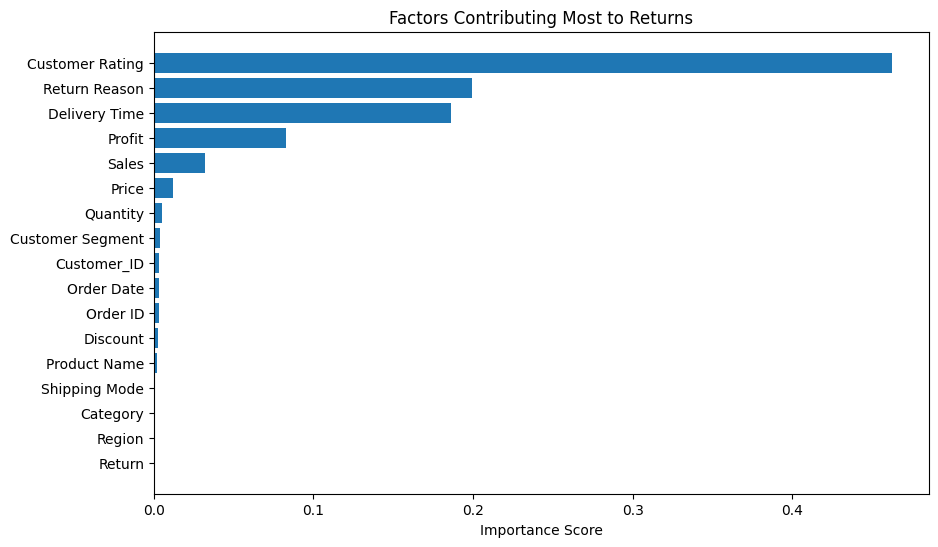

In [ ]:
model.fit(X_train, y_train)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Factors Contributing Most to Returns")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
category_return = df.groupby('Category')['Returned'].mean().sort_values(ascending=False)

print(category_return)
shipping_return = df.groupby('Shipping Mode')['Returned'].mean().sort_values(ascending=False)

print(shipping_return)
segment_return = df.groupby('Customer Segment')['Returned'].mean().sort_values(ascending=False)

print(segment_return)
region_return = df.groupby('Region')['Returned'].mean().sort_values(ascending=False)

print(region_return)
numeric_cols = [
    'Quantity',
    'Sales',
    'Profit',
    'Price',
    'Discount',
    'Delivery Time',
    'Customer Rating',
    'Returned'
]

print(df[numeric_cols].corr()['Returned'].sort_values(ascending=False))

Category
3    0.800000
2    0.610644
0    0.604568
1    0.603339
Name: Returned, dtype: float64
Shipping Mode
2    0.612769
1    0.608696
0    0.592973
Name: Returned, dtype: float64
Customer Segment
1    0.671429
0    0.538286
Name: Returned, dtype: float64
Region
1    0.613769
3    0.604236
0    0.603488
2    0.598639
4    0.500000
Name: Returned, dtype: float64
Returned           1.000000
Delivery Time      0.699017
Discount          -0.046458
Price             -0.129588
Quantity          -0.140673
Sales             -0.145786
Profit            -0.147514
Customer Rating   -0.747311
Name: Returned, dtype: float64


          Total_Orders  Returned_Orders  Return_Rate (%)
Category                                                
3                    5                4        80.000000
2                  357              218        61.064426
0                 1401              847        60.456817
1                 1737             1048        60.333909


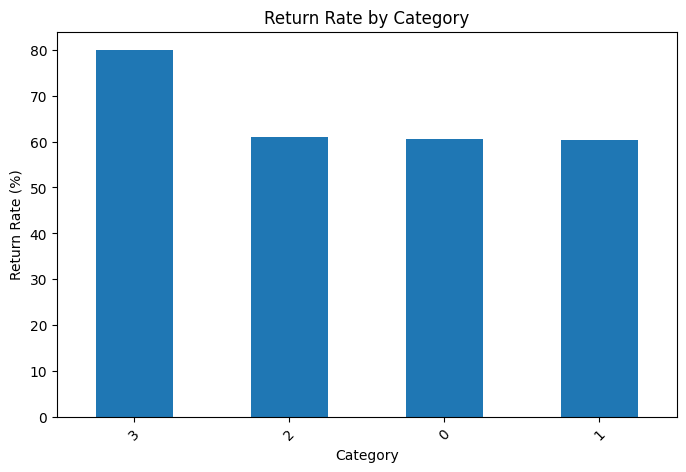

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Group by category and calculate return statistics
category_returns = df.groupby('Category').agg(
    Total_Orders=('Returned', 'count'),
    Returned_Orders=('Returned', 'sum')
)

# Calculate Return Rate
category_returns['Return_Rate (%)'] = (
    category_returns['Returned_Orders'] /
    category_returns['Total_Orders']
) * 100

# Sort by highest return rate
category_returns = category_returns.sort_values(
    by='Return_Rate (%)',
    ascending=False
)

print(category_returns)

category_returns['Return_Rate (%)'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Category_Encoded'] = le.fit_transform(df['Category'].fillna('Blank'))

mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print(mapping)

{'Accessories': np.int64(0), 'Blank': np.int64(1), 'Electronics': np.int64(2), 'Office': np.int64(3)}


          Average_Delivery_Time  Total_Orders
Returned                                     
0                      3.569053          1383
1                      8.483231          2117
               Total_Orders  Returned_Orders  Return_Rate (%)
Delivery Time                                                
1                       282               46        16.312057
2                       291               49        16.838488
3                       283               41        14.487633
4                       289               61        21.107266
5                       266               83        31.203008
6                       315              170        53.968254
7                       323              248        76.780186
8                       287              267        93.031359
9                       266              254        95.488722
10                      316              316       100.000000
11                      289              289       100.000000
12        

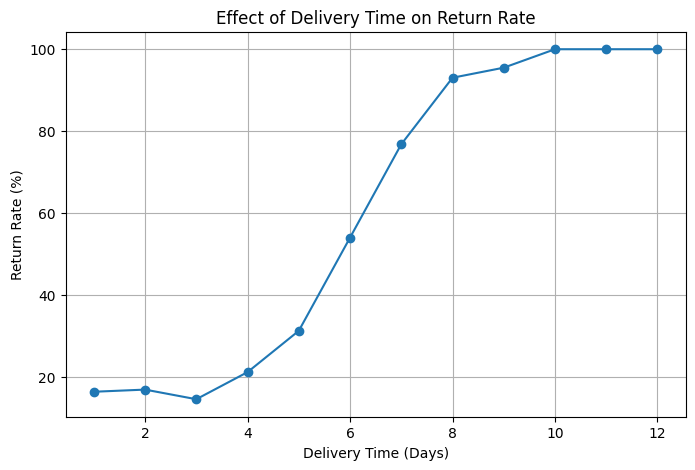

In [ ]:
import pandas as pd

# Average delivery time for returned vs non-returned orders
delivery_analysis = df.groupby('Returned').agg(
    Average_Delivery_Time=('Delivery Time', 'mean'),
    Total_Orders=('Returned', 'count')
)

print(delivery_analysis)
#print(df['Returned'])
# Return rate for each delivery time
delivery_return = df.groupby('Delivery Time').agg(
    Total_Orders=('Returned', 'count'),
    Returned_Orders=('Returned', 'sum')
)

delivery_return['Return_Rate (%)'] = (
    delivery_return['Returned_Orders'] /
    delivery_return['Total_Orders']
) * 100

delivery_return = delivery_return.sort_values(
    by='Delivery Time'
)

print(delivery_return)

plt.figure(figsize=(8,5))

plt.plot(
    delivery_return.index,
    delivery_return['Return_Rate (%)'],
    marker='o'
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Return Rate (%)")
plt.title("Effect of Delivery Time on Return Rate")
plt.grid(True)

plt.show()

                  Total_Orders  Returned_Orders  Return_Rate (%)
Customer Segment                                                
1                         1750             1175        67.142857
0                         1750              942        53.828571


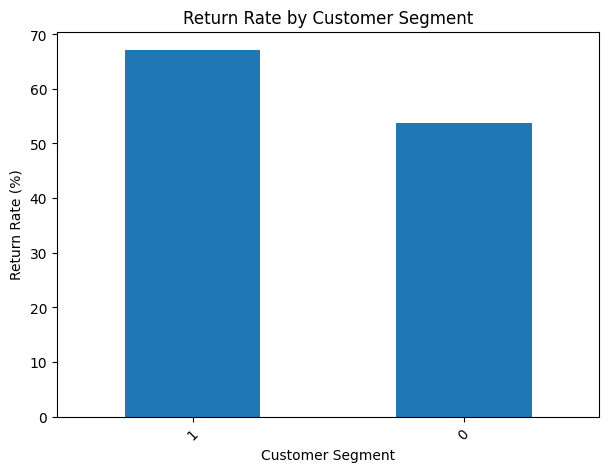

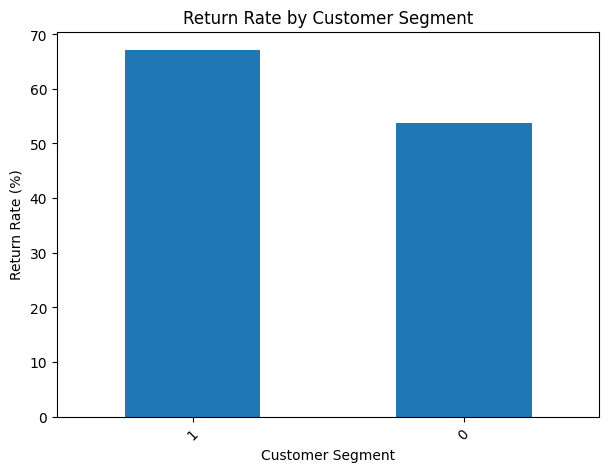

In [ ]:
# Customer Segment-wise return analysis
customer_groups = df.groupby('Customer Segment').agg(
    Total_Orders=('Returned', 'count'),
    Returned_Orders=('Returned', 'sum')
)

# Calculate return rate
customer_groups['Return_Rate (%)'] = (
    customer_groups['Returned_Orders'] /
    customer_groups['Total_Orders']
) * 100

# Sort by highest return rate
customer_groups = customer_groups.sort_values(
    by='Return_Rate (%)',
    ascending=False
)

print(customer_groups)
import matplotlib.pyplot as plt

customer_groups['Return_Rate (%)'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Return Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.show()

customer_groups['Return_Rate (%)'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Return Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.show()